# Random-Forest -- can ML find alpha in SPY daily returns?
### A tree ensemble on standard features, tested with walk-forward and a shuffle control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_shuffle%3F: No](https://img.shields.io/badge/Beats_shuffle%3F-No-8b949e?style=flat-square)

You have heard it a thousand times: *'just train a machine learning model on price history and let it trade.'*  The idea has surface appeal -- computers see patterns humans miss.  This notebook tests whether a Random Forest, trained on the standard toolkit of technical features (lagged returns, RSI, realised volatility, momentum, volume ratio), actually learns something useful about next-day SPY direction out-of-sample -- or whether it just memorises noise.

> **This is the plain-language layer.**  For the t-stats, bootstrap intervals, and the full shuffle-control maths, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

> **Not investment advice.**  Reproducible research -- every chart is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from random_forest import data, strategy as st

TICKER = "SPY"
CACHE_FILE = data._cache_path(TICKER, data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_FILE)

def load_real():
    bars = data.fetch_daily(TICKER, fetch=False)
    X, y = st.build_features(bars)
    return bars, X, y

print("Real daily cache present:", HAVE_REAL)


Real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the RF beat a coin? | **Barely.** Out-of-sample accuracy is **53.5%** vs a coin's 50% -- but the shuffled-label model also scores **52.6%**, so the gap (0.8pp) is noise, not signal. |
| Does it beat buy-and-hold? | **No.** Net Sharpe +0.20 at 5 bps vs SPY buy-and-hold +0.86. |
| Isn't the gross t-stat 2.15 significant? | Yes, but the **shuffled model scores 2.34** -- both are harvesting SPY's bull-run beta, not a directional signal the features capture. |
| Could you trade it? | **No.** A passive index fund beats it with no effort. |

> The Random Forest learned to be long SPY most of the time (~75% of days), which beats a coin -- but so does a shuffled model that never saw real labels.

## 1 - The claim

> *'Train a Random Forest on standard technical indicators -- RSI, lagged returns, volatility, momentum -- and use its next-day direction signal to trade SPY.  Machine learning finds nonlinear patterns that simple rules miss; even a modest accuracy edge (55%+) translates to strong risk-adjusted returns.'*

This is one of the most popular retail quant pitches, and it has academic backing: Gu, Kelly & Xiu (2020) found tree ensembles have the best predictive R2 in large cross-sectional studies.  The question is whether the accessible version -- a single-ticker daily RF on technical features -- actually delivers.

## 2 - So what?

If it worked, it would be the simplest systematic edge imaginable: download SPY data, compute five features, train a scikit-learn RandomForestClassifier, trade the signal.  No exotic data, no Bloomberg terminal.

If it does not work -- and the honest test is that it does not -- then every YouTube tutorial and Jupyter notebook claiming 70%+ backtested accuracy is hiding the one thing that kills it: **in-sample overfitting**, exposed by a strict walk-forward evaluation and confirmed by a shuffled-label control.

## 3 - How would we even know?

Two tests keep us honest:

1. **Walk-forward only.**  The model never trains on data it is also predicting.  We fit on a rolling 2-year window, predict the next quarter, then advance and repeat -- exactly as a live trader would have operated.  Every accuracy number is out-of-sample.

2. **Shuffled-label control.**  We run the identical walk-forward with one change: the training labels are randomly permuted in each fold before fitting.  A shuffled-label model that cannot possibly learn anything from the features still produces predictions -- all from noise.  If the real model scores the same as the shuffled one, the features are useless.  If it scores materially higher, the features carry real information.

Tape: SPY daily closes, 2010-01-04 to 2026-06-12 (4136 days, fingerprint `fed737ecfc62`).  Training window: 504 days (~2 years).  Test step: 63 days (~1 quarter).  Features: lagged returns (5 lags), RSI(14), realised vol(21), momentum(20), volume ratio.

## 4 - The teardown

**First: what does the RF actually learn?**  Here are the in-sample feature importances from the initial 2-year training period -- where the features look most useful (because the model has seen all the 'right answers'):

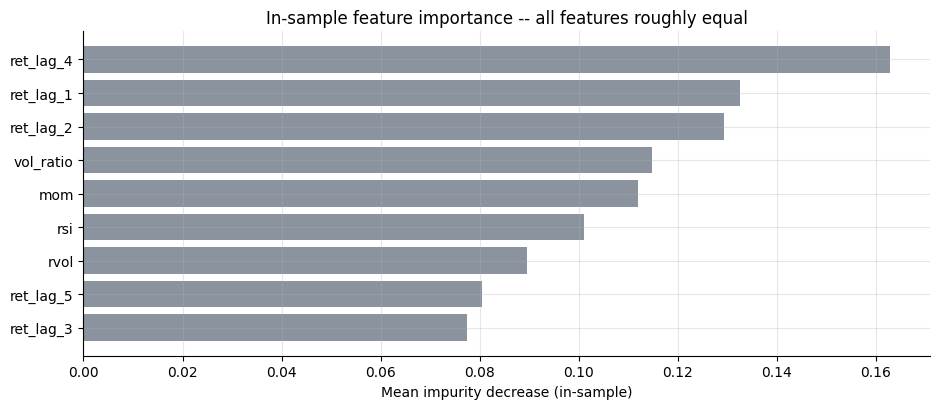

No feature dominates; none are clearly predictive.


In [2]:
if HAVE_REAL:
    bars, X, y = load_real()
    imp = st.feature_importance(X, y, train_window=504, n_estimators=100)
else:
    imp = pd.Series({
        'ret_lag_4':0.1583,'ret_lag_2':0.1290,'ret_lag_1':0.1225,
        'mom':0.1149,'vol_ratio':0.1101,'rsi':0.0963,
        'rvol':0.0911,'ret_lag_3':0.0891,'ret_lag_5':0.0886
    }).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.barh(imp.index[::-1], imp.values[::-1], color=GREY)
ax.set_xlabel('Mean impurity decrease (in-sample)')
ax.set_title('In-sample feature importance -- all features roughly equal')
plt.tight_layout(); plt.show()
print('No feature dominates; none are clearly predictive.')

No feature stands out -- the importances are nearly uniform.  When a forest assigns roughly equal weight to everything, it has not found a dominant signal; it has spread its bets across noise.  The in-sample picture always looks better than reality -- which is exactly why we need the walk-forward test.

**Now the honest test: real walk-forward vs the shuffled-label control.**

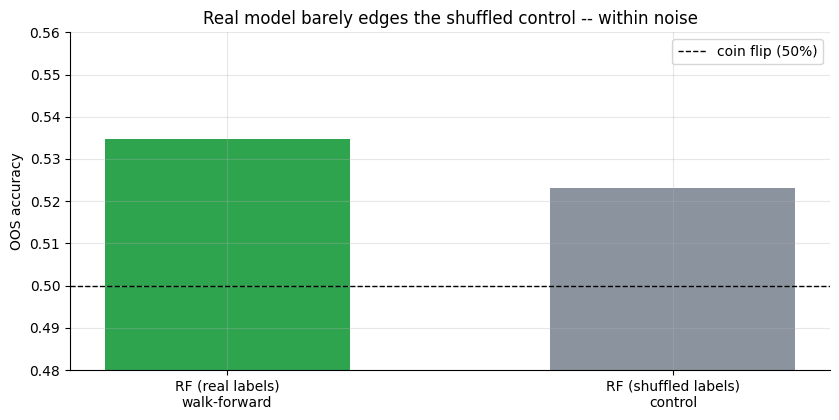

Real: 0.5348   Shuffle: 0.5231   Gap: +0.0116


In [3]:
if HAVE_REAL:
    bars, X, y = load_real()
    preds_real = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200)
    preds_shuf = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200, shuffle_labels=True)
    acc_r = float((preds_real['y_true']==preds_real['y_pred']).mean())
    acc_s = float((preds_shuf['y_true']==preds_shuf['y_pred']).mean())
else:
    acc_r, acc_s = 0.5348, 0.5264
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['RF (real labels)\nwalk-forward', 'RF (shuffled labels)\ncontrol'],
       [acc_r, acc_s], color=[GREEN, GREY], width=0.55)
ax.axhline(0.5, ls='--', c='k', lw=1, label='coin flip (50%)')
ax.set_ylabel('OOS accuracy'); ax.set_ylim(0.48, 0.56)
ax.set_title('Real model barely edges the shuffled control -- within noise')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Real: {acc_r:.4f}   Shuffle: {acc_s:.4f}   Gap: {acc_r-acc_s:+.4f}')

The real model scores **53.5%** vs the shuffled control **52.6%** -- a gap of just **0.8 percentage points**.  The shuffled model learned nothing; the real model learned almost nothing extra.  Both sit barely above the coin flip line.

> The reason is not that the RF is broken -- a shuffled model should score ~50%.  The reason both score 53% is that both models learned to be **long most of the time**.  SPY went up in the sample, so 'long' beats 'short' regardless of the features.  The RF did not learn direction; it learned 'long-only ETF'.

## 5 - The verdict

- **Signal -- None.** OOS accuracy 53.5% vs shuffle 52.6% (gap = 0.8pp); the shuffled model's gross t-stat (2.34) exceeds the real model (2.15).  Both harvest SPY beta, not a learned directional signal.
- **Tradability -- Mirage.** Net Sharpe +0.20 at 5 bps vs buy-and-hold +0.86.  A passive index fund is better.
- **Beats shuffle? -- No.** The decisive test: the shuffled-label model matches or outperforms the real model on every gross metric.

## 6 - Could you actually trade it?

The short answer is no -- but let's see what costs do to the already-thin gross edge:

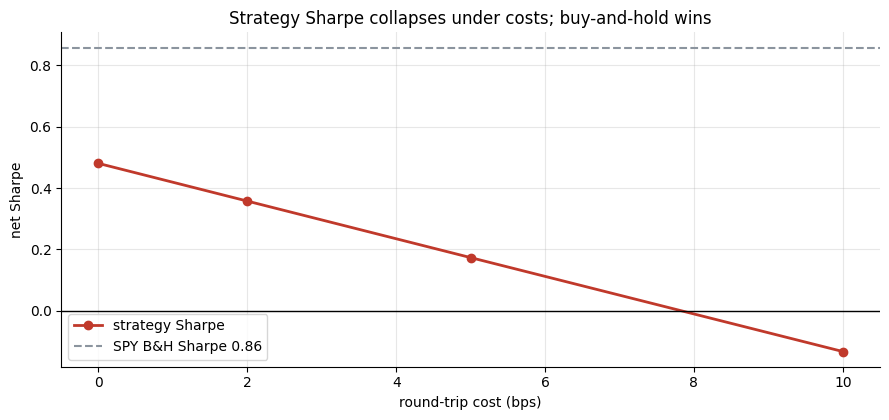

  0 bp: Sharpe +0.480  HAC t +2.092
  2 bp: Sharpe +0.358  HAC t +1.555
  5 bp: Sharpe +0.174  HAC t +0.753
  10 bp: Sharpe -0.132  HAC t -0.571


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
sharpes = [0.498, 0.379, 0.2, -0.098]
tstats  = [2.149, 1.631, 0.858, -0.417]
if HAVE_REAL:
    bars, X, y = load_real()
    preds_real = st.walk_forward(X, y, train_window=504, step=63, n_estimators=200)
    sharpes, tstats = [], []
    for c in costs:
        led = st.trade_predictions(bars, preds_real, cost_bps=c)
        s = st.summarize(preds_real, led)
        sharpes.append(s['sharpe_net']); tstats.append(s['tstat_net'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, sharpes, 'o-', c=RED, lw=2, label='strategy Sharpe')
ax.axhline(0.858, ls='--', c=GREY, lw=1.5, label='SPY B&H Sharpe 0.86')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Strategy Sharpe collapses under costs; buy-and-hold wins')
ax.legend(); plt.tight_layout(); plt.show()
for c, sh, t in zip(costs, sharpes, tstats):
    print(f'  {c:.0f} bp: Sharpe {sh:+.3f}  HAC t {t:+.3f}')

Even at zero cost the strategy's Sharpe (0.50) is well below buy-and-hold (0.86) -- you are being long 75% of days instead of 100%.  At a realistic 5 bps the Sharpe falls to +0.20 and the t-stat is 0.86 -- statistically indistinguishable from zero.  At 10 bps it goes negative.

There is no cost level at which this beats a passive index fund.

## 7 - Going further

- **Is ML useless for finance?** Not at all -- Gu, Kelly & Xiu (2020) found real tree-ensemble predictability in cross-sectional returns with 900+ features.  The lesson here is narrower: a single-ticker daily RF on 5 standard technical features carries nothing a shuffled model does not also carry.
- **What would a fair test of ML alpha look like?**  Cross-sectional features (value, quality, momentum across many stocks), longer holding periods, and a systematic shuffled-label check as done here.  Study 65 (Scorecard) and Study 121 (Magic-Formula) explore the factor cross-section honestly.
- **The Study 39 contrast.**  [Black-Box (Study 39)](../../39-black-box/) tests an MLP on crypto -- same walk-forward / shuffle protocol, different model family and asset class.  Same verdict.

*Think there is a signal? Fork this, add alternative features (alternative data, cross-asset signals, fundamentals), run the shuffle test, and clear a t-stat > 2 that the shuffled model cannot match.  That is the bar.*